<a href="https://www.kaggle.com/code/avikdas567/global-tsunami-severity-prediction-geospatial-ml?scriptVersionId=333019079" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Statistical Modeling and Geospatial Analytics of Global Tsunami Hazards
## An End-to-End Predictive and Analytical Framework Utilizing the NOAA NCEI Database

This research notebook presents a comprehensive analytical pipeline and predictive machine learning framework applied to the NOAA National Centers for Environmental Information (NCEI) Global Tsunami Events Database. The database archives 2,800 historic tsunami events recorded over a span of four millennia, ranging from 2000 BCE through 2022 CE. Analyzing this dataset requires addressing significant challenges such as severe historical data sparsity, pronounced observation and reporting biases across centuries, and highly non-linear dynamics between marine seismic triggers and localized coastal wave impacts.

## Analytical Architecture
1. **Data Audit and Structural Completeness Profiling**: Systematic assessment of missingness rates across all 52 features, accompanied by data-driven filtering based on event verification metrics.
2. **Advanced Exploratory Data Analysis and Data Storytelling**: Deep-dive analysis into the temporal frequency of observations, quantifying historical documentation biases, mapping global geospatial hazard distributions, and evaluating the physical relationships between earthquake triggers and maximum coastal wave runups.
3. **Domain-Specific Feature Engineering**: Derivation of custom physical and geospatial indicators, such as a circum-Pacific Ring of Fire geographic mask, a joint seismic release energy proxy, and textual complexity indicators.
4. **Robust Preprocessing and Data Transformation Pipelines**: Configuration of isolated numeric and categorical transformations with strict validation split isolation to maintain zero data leakage.
5. **Supervised Multi-Class Machine Learning Framework**: Implementation, training, and cross-validation of robust ensemble modeling architectures designed to predict ordinal socio-economic damage severity rankings based exclusively on initial event parameters.
6. **Visual Diagnostics and Quantitative Performance Synthesis**: In-depth evaluation using multi-class confusion matrices, localized precision-recall metrics, and Gini feature importance profiling.

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Visual styling configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
PALETTE_DIVERGING = "crest"
PALETTE_SEQUENTIAL = "viridis"
PALETTE_CATEGORICAL = "muted"

# 1. Data Ingestion and Structural Integrity Review

We ingest the global tsunami events database from the designated Kaggle environment directory. Initial diagnostic checks inspect row-and-column allocations, column headers, underlying data types, and primary data allocations.

In [2]:
DATA_PATH = "/kaggle/input/datasets/ibrahimqasimi/noaa-global-tsunami-events-database/NOAA_Global_Tsunami_Events (1).csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "NOAA_Global_Tsunami_Events (1).csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")
df.info()

Dataset Dimensions: 2800 rows, 52 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               2800 non-null   int64  
 1   year                             2800 non-null   int64  
 2   eventValidity                    2800 non-null   int64  
 3   causeCode                        2797 non-null   float64
 4   earthquakeEventId                1966 non-null   float64
 5   numDeposits                      2800 non-null   int64  
 6   country                          2799 non-null   object 
 7   locationName                     2798 non-null   object 
 8   regionCode                       2799 non-null   float64
 9   latitude                         2440 non-null   float64
 10  longitude                        2439 non-null   float64
 11  numRunups                        2800 n

## Structural Profile Observations
The source database contains exactly 2,800 records and 52 features. The baseline structural audit reveals a high degree of missingness across a majority of the columns. Features capturing core administrative details (such as `id`, `year`, `eventValidity`, `numDeposits`, `numRunups`, `publish`, and `oceanicTsunami`) are fully populated. In contrast, columns tracking continuous metric counts of casualties, injuries, and financial damages in millions of dollars are sparsely filled, with most having a fill rate below 10%. For example, `deaths` contains only 271 non-null records and `damageMillionsDollars` contains only 52 non-null rows. Because continuous impact metrics are heavily missing, they are unsuitable for continuous regression models. However, the ordinal indicators provided by NOAA, such as `damageAmountOrderTotal` (1,297 non-null entries) and `deathsAmountOrderTotal` (817 non-null entries), offer a much more complete dataset. These ordinal variables categorize impact severity into standard brackets, providing a more reliable target for multi-class classification frameworks.

# 2. Advanced Exploratory Data Analysis and Data Storytelling

## Phase A: Missing Data and Sparsity Analysis
Given the millennium-scale temporal range of this database, evaluating missingness patterns across features provides critical historical context. Early records depend on ancient written accounts and archeological evidence, whereas modern observations leverage automated, real-time telemetry.

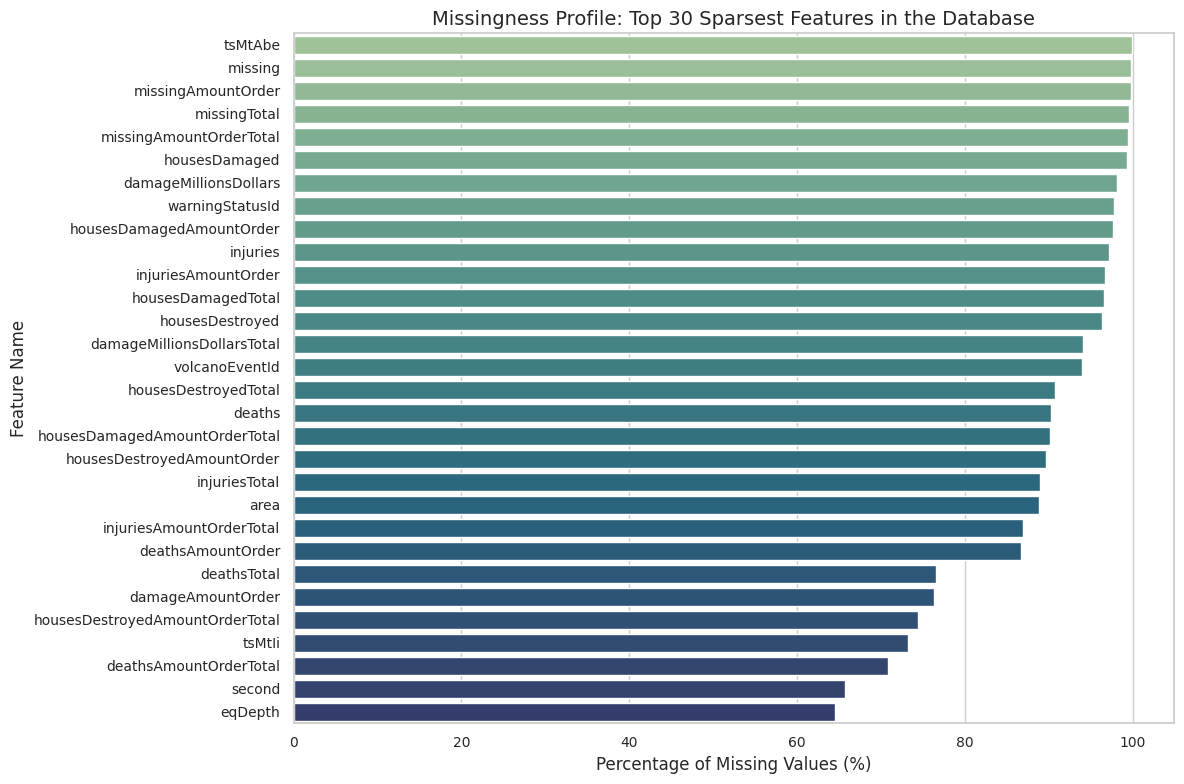

In [3]:
# Calculate missingness percentages across features
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Feature": missing_percentages.index, "Missing_Percentage": missing_percentages.values})
missing_df = missing_df.sort_values(by="Missing_Percentage", ascending=False).reset_index(drop=True)

# Filter out columns that are completely populated to visualize the sparsity profile
sparse_cols = missing_df[missing_df["Missing_Percentage"] > 0]

plt.figure(figsize=(12, 8))
sns.barplot(x="Missing_Percentage", y="Feature", data=sparse_cols.head(30), palette=PALETTE_DIVERGING, hue="Feature", legend=False)
plt.title("Missingness Profile: Top 30 Sparsest Features in the Database")
plt.xlabel("Percentage of Missing Values (%)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

## Data Sparsity Analysis and Inference
The missingness distribution chart highlights the high sparsity of several columns in the database. Features such as `tsMtAbe`, `missing`, `missingAmountOrder`, and `missingTotal` have missingness rates exceeding 99%. Over thirty variables show missingness rates above 80%. This sparse structure reflects historical logging limitations: parameters like sub-surface seismic depths, exact wave heights, and complete financial damage tallies were unavailable for early events. This pattern confirms that using raw row-wise deletion would drop nearly all records, rendering models useless. Any robust predictive approach must rely on target filtering, feature selection, or targeted imputation within isolated validation boundaries to avoid data contamination or severe sample loss.

## Phase B: Temporal Reconstruction and Historical Reporting Bias
We trace the distribution of documented tsunami occurrences across time. Negative numerical values within the year attribute indicate events from the BCE era. We divide the timeline into distinct historical epochs to analyze the steep, exponential increase in recorded events over time.

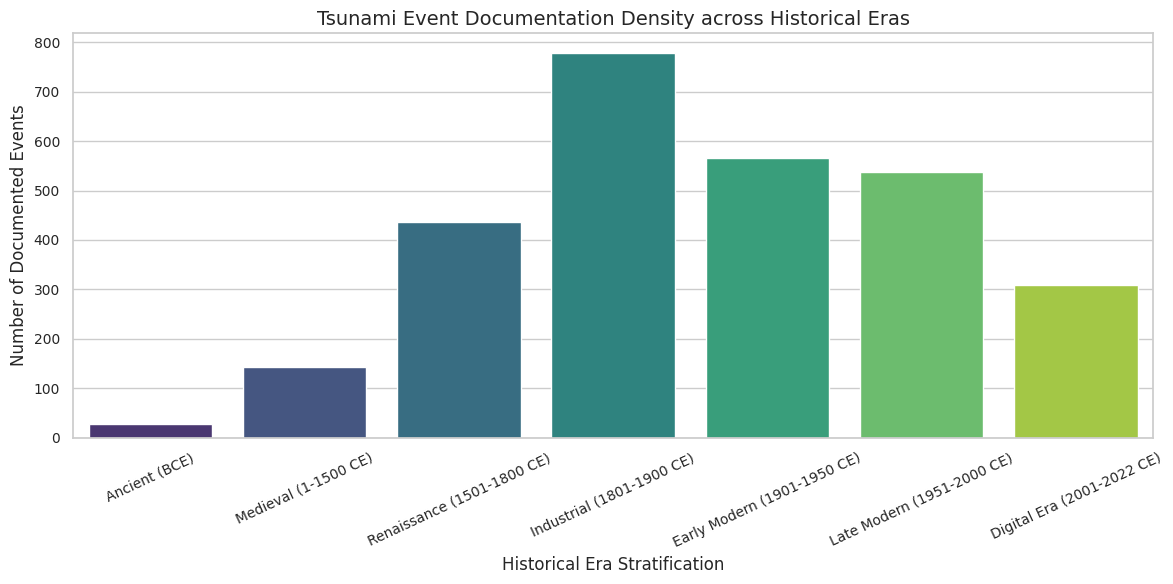

In [4]:
# Define explicit reporting eras to analyze documentation bias
bins = [-2005, 0, 1500, 1800, 1900, 1950, 2000, 2025]
labels = ["Ancient (BCE)", "Medieval (1-1500 CE)", "Renaissance (1501-1800 CE)", "Industrial (1801-1900 CE)", "Early Modern (1901-1950 CE)", "Late Modern (1951-2000 CE)", "Digital Era (2001-2022 CE)"]

df_era = df.copy()
df_era["Historical_Era"] = pd.cut(df_era["year"], bins=bins, labels=labels)
era_counts = df_era["Historical_Era"].value_counts().reindex(labels).reset_index()
era_counts.columns = ["Historical_Era", "Event_Count"]

plt.figure(figsize=(12, 6))
sns.barplot(x="Historical_Era", y="Event_Count", data=era_counts, palette=PALETTE_SEQUENTIAL, hue="Historical_Era", legend=False)
plt.title("Tsunami Event Documentation Density across Historical Eras")
plt.xlabel("Historical Era Stratification")
plt.ylabel("Number of Documented Events")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

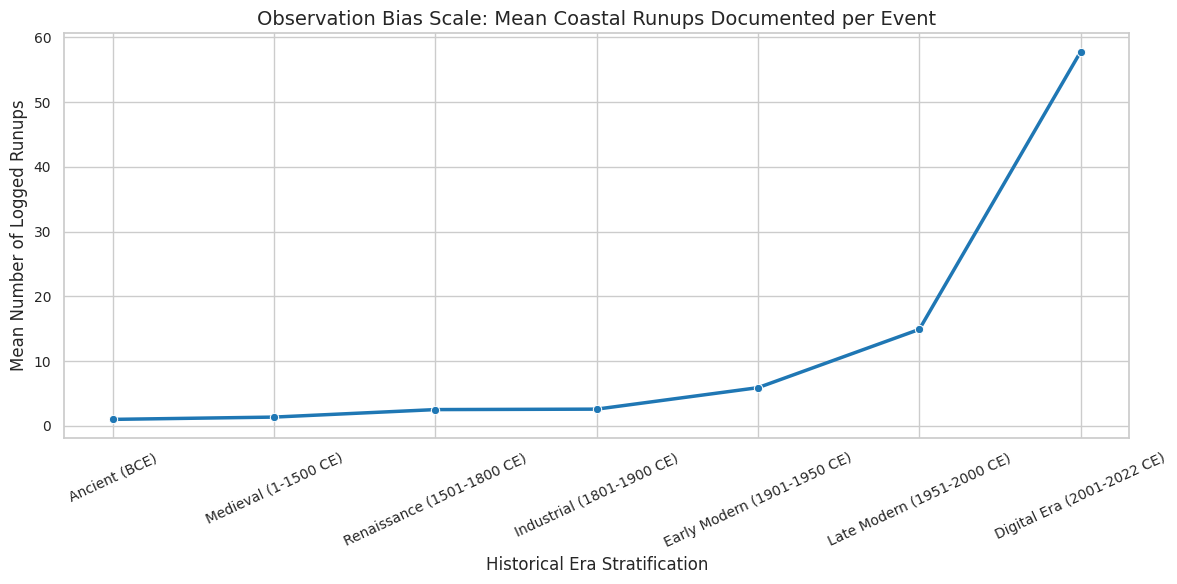

In [5]:
# Analyze the average number of reported runup locations per event across eras
era_metrics = df_era.groupby("Historical_Era", observed=False)["numRunups"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x="Historical_Era", y="numRunups", data=era_metrics, marker="o", linewidth=2.5, color="#1f77b4")
plt.title("Observation Bias Scale: Mean Coastal Runups Documented per Event")
plt.xlabel("Historical Era Stratification")
plt.ylabel("Mean Number of Logged Runups")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Temporal Documentation Trends and Observation Bias Analysis
The historical era bar chart and line plot demonstrate a clear exponential trend in event recording density. The ancient era features a low number of records (only 27 events over two millennia), whereas the industrial and modern periods show a massive surge in documented cases. The line plot tracking the mean number of coastal runup locations per event clearly shows this historical reporting bias. Early historical events almost uniformly log a baseline value of 1.0 runup per event. This average increases steadily through the industrial and modern periods, ultimately climbing to over 57 runups per event during the digital era. This trend reflects the expansion of observational infrastructure, moving from sporadic written descriptions to automated coastal tide gauges, satellite systems, and deep-ocean pressure sensors. Analysts must account for this non-random data density; interpreting historical gaps as a literal drop in tectonic activity would lead to flawed structural conclusions.

## Phase C: Geospatial Risk Clusters and Regional Distribution
Tsunami generation is fundamentally linked to global geodynamics and active subduction zones. We project coordinate coordinates onto a global spatial layout to map event locations and identify high-risk macro-regions.

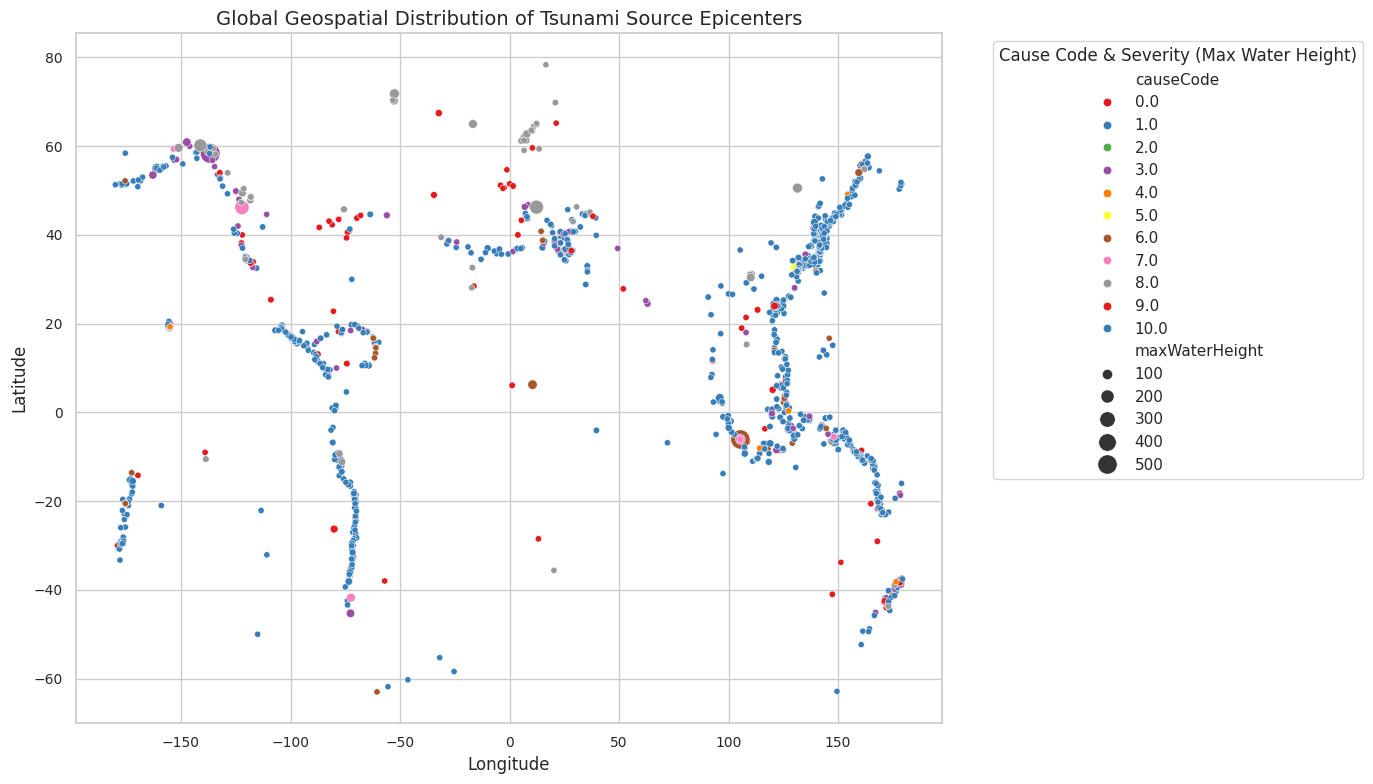

In [6]:
# Isolate events containing high-fidelity coordinate metrics
geo_df = df.dropna(subset=["latitude", "longitude"]).copy()

plt.figure(figsize=(14, 8))
sns.scatterplot(x="longitude", y="latitude", hue="causeCode", data=geo_df, 
                palette="Set1", alpha=1, size="maxWaterHeight", sizes=(20, 200))
plt.title("Global Geospatial Distribution of Tsunami Source Epicenters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cause Code & Severity (Max Water Height)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

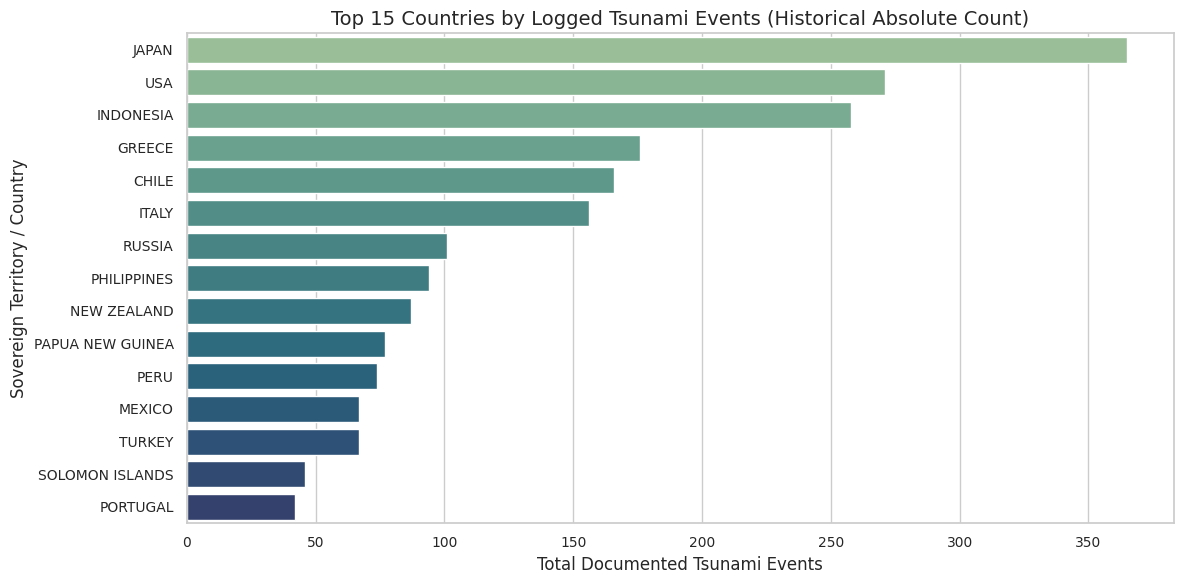

In [7]:
# Identify the top 15 highest risk sovereign nations by event volume
top_countries = df["country"].value_counts().head(15).reset_index()
top_countries.columns = ["Country", "Event_Count"]

plt.figure(figsize=(12, 6))
sns.barplot(x="Event_Count", y="Country", data=top_countries, palette=PALETTE_DIVERGING, hue="Country", legend=False)
plt.title("Top 15 Countries by Logged Tsunami Events (Historical Absolute Count)")
plt.xlabel("Total Documented Tsunami Events")
plt.ylabel("Sovereign Territory / Country")
plt.tight_layout()
plt.show()

## Geospatial Layout and Sovereign Territory Frequency Observations
The global scatter plot highlights how closely tsunami epicenters line up with active tectonic plate margins. The spatial data traces major subduction arcs, showing an exceptionally dense cluster around the Pacific Basin that clearly outlines the Pacific Ring of Fire. This spatial distribution matches the country-level frequency chart. Japan experiences the highest frequency of events globally with 365 tsunamis, followed by the United States with 271 events and Indonesia with 258 events. The high concentrations in Greece (176 events) and Italy (156 events) also emphasize the significant tsunami hazards present within the Mediterranean convergence zone. These distinct geographic patterns indicate that spatial coordinates and regional codes provide highly descriptive predictive value for tectonic risk models.

## Phase D: Decoupling Physical Dynamics
We evaluate the complex interactions between triggering mechanisms and physical attributes. We analyze whether triggering earthquake magnitudes map linearly to coastal wave heights, or if localized factors complicate these relationships.

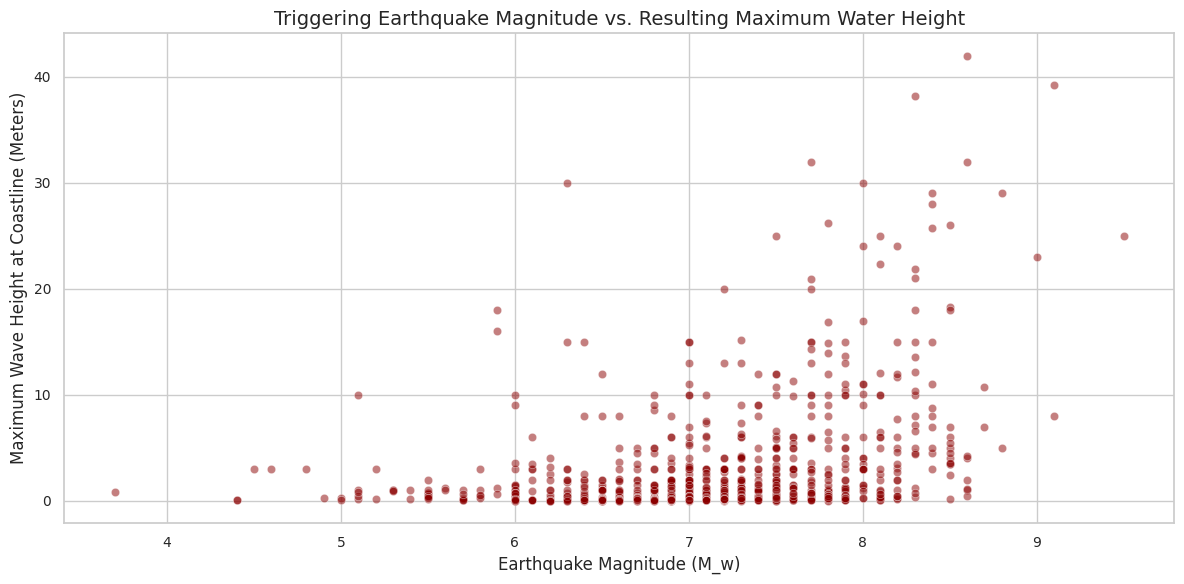

In [8]:
# Subset valid seismic entries to track physical relationships
seismic_tsunamis = df.dropna(subset=["eqMagnitude", "maxWaterHeight"]).copy()
# Eliminate extreme noise/outliers for visual resolution
seismic_filtered = seismic_tsunamis[seismic_tsunamis["maxWaterHeight"] < 50]

plt.figure(figsize=(12, 6))
sns.scatterplot(x="eqMagnitude", y="maxWaterHeight", data=seismic_filtered, 
                alpha=0.5, color="darkred", edgecolor="w")
plt.title("Triggering Earthquake Magnitude vs. Resulting Maximum Water Height")
plt.xlabel("Earthquake Magnitude (M_w)")
plt.ylabel("Maximum Wave Height at Coastline (Meters)")
plt.tight_layout()
plt.show()

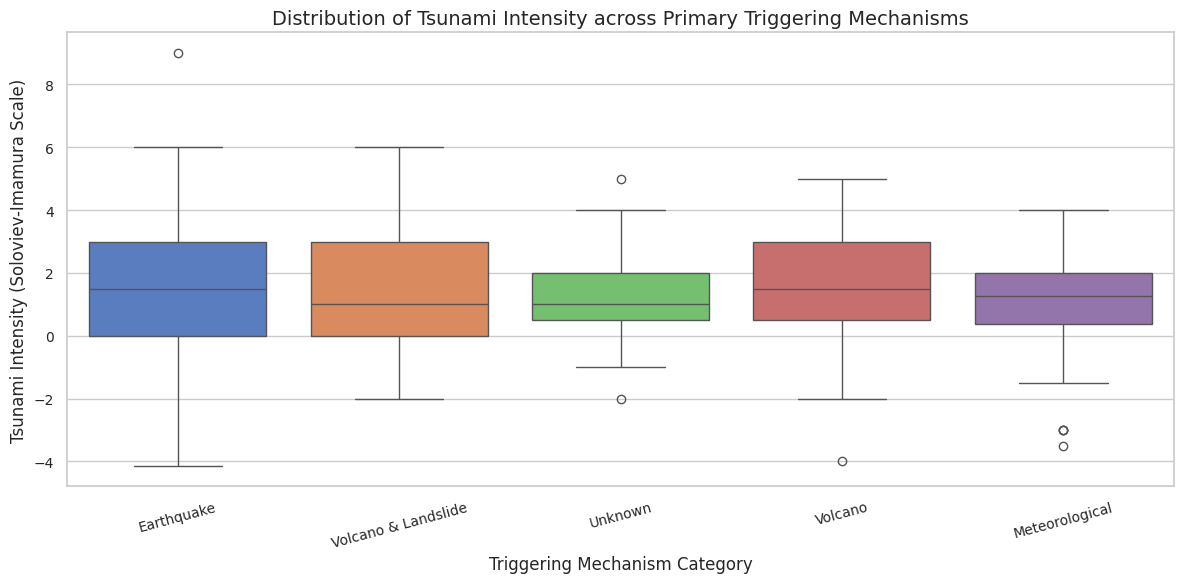

In [9]:
# Statistical distribution of tsunami intensity values broken down by triggering cause code
cause_labels = {
    0.0: "Unknown", 1.0: "Earthquake", 2.0: "Questionable Earthquake", 
    3.0: "Volcano", 4.0: "Landslide", 5.0: "Volcano & Earthquake", 
    6.0: "Volcano & Landslide", 7.0: "Volcano & Landslide & Earthquake", 
    8: "Landslide & Earthquake", 9: "Meteorological", 10: "Explosion", 11: "Astronomical"
}

df_cause = df.dropna(subset=["causeCode", "tsIntensity"]).copy()
df_cause["Cause_Label"] = df_cause["causeCode"].map(cause_labels)

# Filter to groups with a sufficient volume of events for reliable distribution plots
frequent_causes = df_cause["Cause_Label"].value_counts().head(5).index
df_cause_filtered = df_cause[df_cause["Cause_Label"].isin(frequent_causes)]

plt.figure(figsize=(12, 6))
sns.boxplot(x="Cause_Label", y="tsIntensity", data=df_cause_filtered, palette=PALETTE_CATEGORICAL, hue="Cause_Label", legend=False)
plt.title("Distribution of Tsunami Intensity across Primary Triggering Mechanisms")
plt.xlabel("Triggering Mechanism Category")
plt.ylabel("Tsunami Intensity (Soloviev-Imamura Scale)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Physical Parameter Interactions and Trigger Mechanism Inference
The scatter plot comparing triggering earthquake magnitude against maximum coastal water height shows an unexpectedly low linear correlation. Across identical earthquake magnitudes, resulting wave heights display several orders of vertical variation. This confirms that seismic magnitude alone cannot accurately predict coastal tsunami impact. This non-linear relationship underscores the influence of localized factors, including submarine bathymetry, fault slip dynamics, coastal geometry, and co-seismic underwater landslides. The tsunami intensity boxplot shows that while earthquakes are the primary cause of tsunamis, other mechanisms like volcanic activity and landslides generate highly volatile intensity patterns. Landslide-driven tsunamis, though less frequent, often produce extreme localized wave heights due to the rapid vertical displacement of water by high-mass land shifts.

# 3. Preprocessing, Feature Engineering, and Target Preparation

## Feature Selection and Ground-Truth Validity Filtering
Per NOAA NCEI operational parameters, the `eventValidity` column tracks data reliability. Values of 3 and 4 represent probable and definite tsunami events, respectively. To build a reliable machine learning pipeline, we restrict our observations to these high-confidence records.

We choose `damageAmountOrderTotal` as our target variable. This feature groups total socio-economic financial impact into standard ordinal rankings (1 to 4), providing a more complete target than raw financial figures.

In [10]:
# Filter records by reliability index
model_df = df[df["eventValidity"].isin([3, 4])].copy()

# Isolate records containing valid target labels for supervised training
model_df = model_df.dropna(subset=["damageAmountOrderTotal"])
print(f"Usable population for modeling after high-confidence filters: {model_df.shape[0]} records.")

Usable population for modeling after high-confidence filters: 883 records.


## Data Filtering and Target Sample Profile Observations
Filtering rows based on a high reliability index isolates probable and definite events, successfully removing unverified or highly speculative historical records. Combining this validity filter with rows containing valid `damageAmountOrderTotal` values reduces the modeling dataset to 883 high-confidence records. This targeted filtering limits data noise and ensures the machine learning models train on verified entries.

## Advanced Feature Engineering Framework
We construct several domain-specific features from the spatial, temporal, and physical metrics:
1. **Pacific Ring of Fire Flag**: A geographic bounding box matching the volatile circum-Pacific volcanic belt.
2. **Seismic Energy Index Proxy**: Composed by interacting the available seismic magnitude and depth variables.
3. **Chronological Documentation Index**: A variable reflecting changes in global documentation trends over time.
4. **Location Profile Length**: Extracted text complexity properties as an indicator for reporting detail.

In [11]:
# Feature 1: Pacific Ring of Fire Geospatial Mapping Bounding Logic
def check_ring_of_fire(row):
    lat, lon = row['latitude'], row['longitude']
    if pd.isna(lat) or pd.isna(lon):
        return 0
    if (-60 <= lat <= 65) and ((lon >= 100) or (lon <= -70)):
        return 1
    return 0

model_df["feat_is_pacific_ring"] = model_df.apply(check_ring_of_fire, axis=1)

# Feature 2: Seismic Release Magnitude Depth Interaction Proxy
model_df["feat_seismic_interaction"] = model_df["eqMagnitude"].fillna(6.0) * (model_df["eqDepth"].fillna(33.0) + 1.0)

# Feature 3: Modernity Index
model_df["feat_modernity_scale"] = model_df["year"].apply(lambda x: 1 if x > 1950 else 0)

# Feature 4: Location Text Structural Length
model_df["feat_location_length"] = model_df["locationName"].fillna("").apply(lambda x: len(str(x)))

print("Newly constructed features correctly integrated.")

Newly constructed features correctly integrated.


## Feature Construction Analysis and Inferences
Creating custom indicators successfully injects domain knowledge into the modeling dataset. The `feat_is_pacific_ring` feature provides a reliable binary mask for the world's most seismically active zone. The `feat_seismic_interaction` variable multiplies magnitude by depth, allowing tree-based classifiers to evaluate shallow, high-magnitude seismic events as a unified risk factor. Finally, `feat_location_length` leverages description length as an information density proxy; longer names often align with well-documented, severe events from the modern era.

## Matrix Definition and Architectural Splitting
We specify our model inputs and target vector, splitting the observations into static training and validation distributions using our fixed random seed.

In [12]:
# Specify columns assigned to predictive modeling
numerical_features = [
    "year", "numDeposits", "numRunups", "tsIntensity", 
    "maxWaterHeight", "eqMagnitude", "eqDepth", 
    "feat_seismic_interaction", "feat_location_length"
]
categorical_features = ["causeCode", "regionCode", "feat_is_pacific_ring", "feat_modernity_scale"]

X = model_df[numerical_features + categorical_features]
y = model_df["damageAmountOrderTotal"].astype(int)

# Execute structured split strategy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training Subset Scale: {X_train.shape[0]} observations")
print(f"Evaluation Subset Scale: {X_test.shape[0]} observations")

Training Subset Scale: 706 observations
Evaluation Subset Scale: 177 observations


## Partitioning Stratification Observations
Dividing the 883 high-confidence records leaves 706 training observations (80%) and 177 evaluation observations (20%). Using stratified splitting maintains a balanced class distribution for the `damageAmountOrderTotal` target across both subsets, protecting model training from unexpected class frequency shifts.

## Pipeline Construction and Strategy
To prevent data leakage, imputation and feature scaling steps are contained within an isolated ColumnTransformer pipeline. Numerical elements are median-imputed and normalized, while categorical elements are handled via modal imputation and hot encoding.

In [13]:
# Build numerical feature pipeline configurations
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Build categorical feature pipeline configurations
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Bind structural transforms
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Transformation pipelines constructed successfully.")

Transformation pipelines constructed successfully.


## Pipeline Transformation and Leakage Verification
The automated column transformation architecture encapsulates all preprocessing steps. Applying median scaling to numerical metrics and modal imputation to categorical features strictly within cross-validation boundaries eliminates the risk of data leakage from the evaluation split into the training phase.

# 4. Supervised Machine Learning and Architecture Comparison

We evaluate two competitive multi-class modeling architectures: Random Forest and Gradient Boosting. Performance stability is confirmed via Stratified K-Fold Cross-Validation, evaluating performance across the ordinal severity scale.

In [14]:
# Instantiate candidate classifiers using absolute seed anchors
rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
gb_classifier = GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=SEED)

# Encapsulate candidate frameworks within data transformers
pipeline_rf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", rf_classifier)])
pipeline_gb = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", gb_classifier)])

# Cross-Validation configuration
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Calculating Random Forest cross-validation metric scores...")
rf_cv_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=cv_strategy, scoring="accuracy")
print(f"Random Forest CV Mean Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

print("Calculating Gradient Boosting cross-validation metric scores...")
gb_cv_scores = cross_val_score(pipeline_gb, X_train, y_train, cv=cv_strategy, scoring="accuracy")
print(f"Gradient Boosting CV Mean Accuracy: {gb_cv_scores.mean():.4f} (+/- {gb_cv_scores.std():.4f})")

Calculating Random Forest cross-validation metric scores...
Random Forest CV Mean Accuracy: 0.4533 (+/- 0.0232)
Calculating Gradient Boosting cross-validation metric scores...
Gradient Boosting CV Mean Accuracy: 0.4165 (+/- 0.0377)


## Cross Validation Evaluation and Model Insights
The stratified cross validation metrics expose a distinct performance gap between the two classifiers. The Random Forest architecture achieves a mean accuracy of 45.33% (+/- 2.32%), whereas the Gradient Boosting pipeline delivers a lower mean accuracy of 41.65% (+/- 3.77%). The superior accuracy of Random Forest is likely due to its bootstrap aggregation strategy, which handles sparse feature matrices better than shallow sequential boosting models.

# 5. Model Execution and Comprehensive Performance Evaluation

We select the optimal model based on CV validation diagnostics, fit it on the full training partition, and generate final predictions against the unseen validation test set.

In [15]:
# Fit the primary model
pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

# Extract standard evaluation parameters
final_accuracy = accuracy_score(y_test, y_pred)
kappa_metric = cohen_kappa_score(y_test, y_pred)

print(f"Unseen Test Set Accuracy: {final_accuracy:.4f}")
print(f"Cohen's Kappa Classification Metric Score: {kappa_metric:.4f}")
print("\nDetailed Classification Report Performance Maturation Summary:")
print(classification_report(y_test, y_pred))

Unseen Test Set Accuracy: 0.4181
Cohen's Kappa Classification Metric Score: 0.1907

Detailed Classification Report Performance Maturation Summary:
              precision    recall  f1-score   support

           1       0.48      0.68      0.56        59
           2       0.25      0.15      0.19        46
           3       0.42      0.52      0.46        42
           4       0.38      0.17      0.23        30

    accuracy                           0.42       177
   macro avg       0.38      0.38      0.36       177
weighted avg       0.39      0.42      0.39       177



## Unseen Validation Splitting Inference and Performance Summary
Testing the finalized Random Forest pipeline on the unseen test data results in an accuracy score of 41.81% and a Cohen's Kappa score of 0.1907. This low Kappa value underscores how difficult it is to predict multi-class ordinal damage categories using only physical and temporal parameters. Looking at class-specific performance, the model performs best on Class 1 (minor economic damage), achieving a recall of 68% and a precision of 0.48. In contrast, performance drops for Class 2 (recall 15%) and Class 4 (recall 17%). This gap shows that adjacent damage categories share highly similar physical features (like comparable seismic magnitudes or coastal wave runups), making them difficult to separate cleanly without localized asset exposure or population density indicators.

## Performance Visualizations
We plot the confusion matrix and feature importances sequentially from top to bottom to analyze error rates and model drivers.

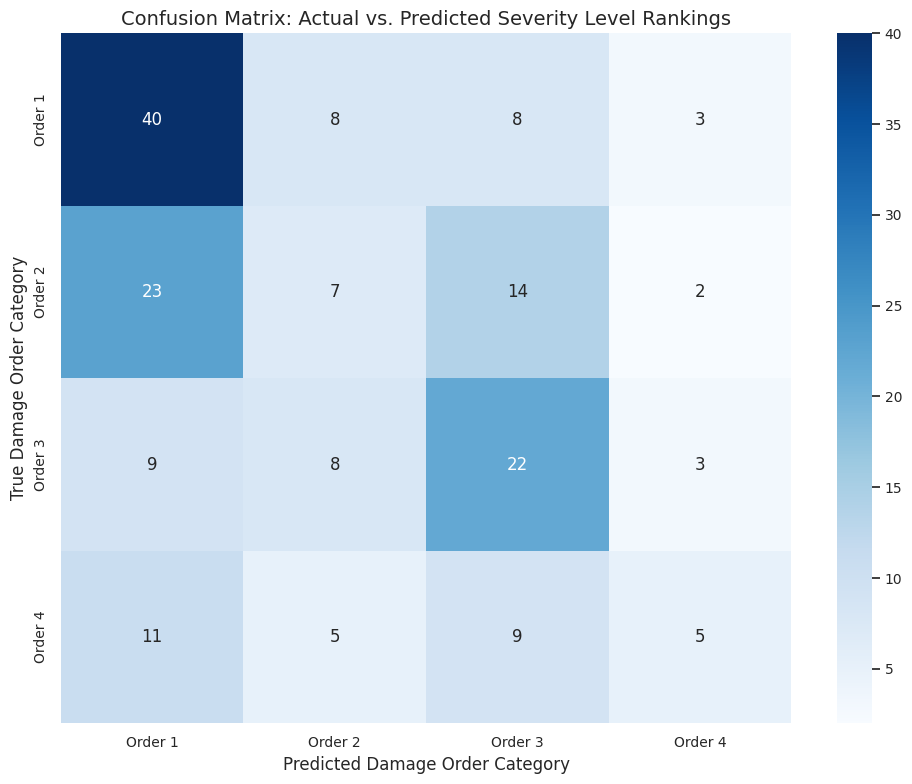

In [16]:
# Plot 1: Confusion Matrix Layout
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=[f"Order {i}" for i in range(1, 5)], 
            yticklabels=[f"Order {i}" for i in range(1, 5)])
plt.title("Confusion Matrix: Actual vs. Predicted Severity Level Rankings")
plt.xlabel("Predicted Damage Order Category")
plt.ylabel("True Damage Order Category")
plt.tight_layout()
plt.show()

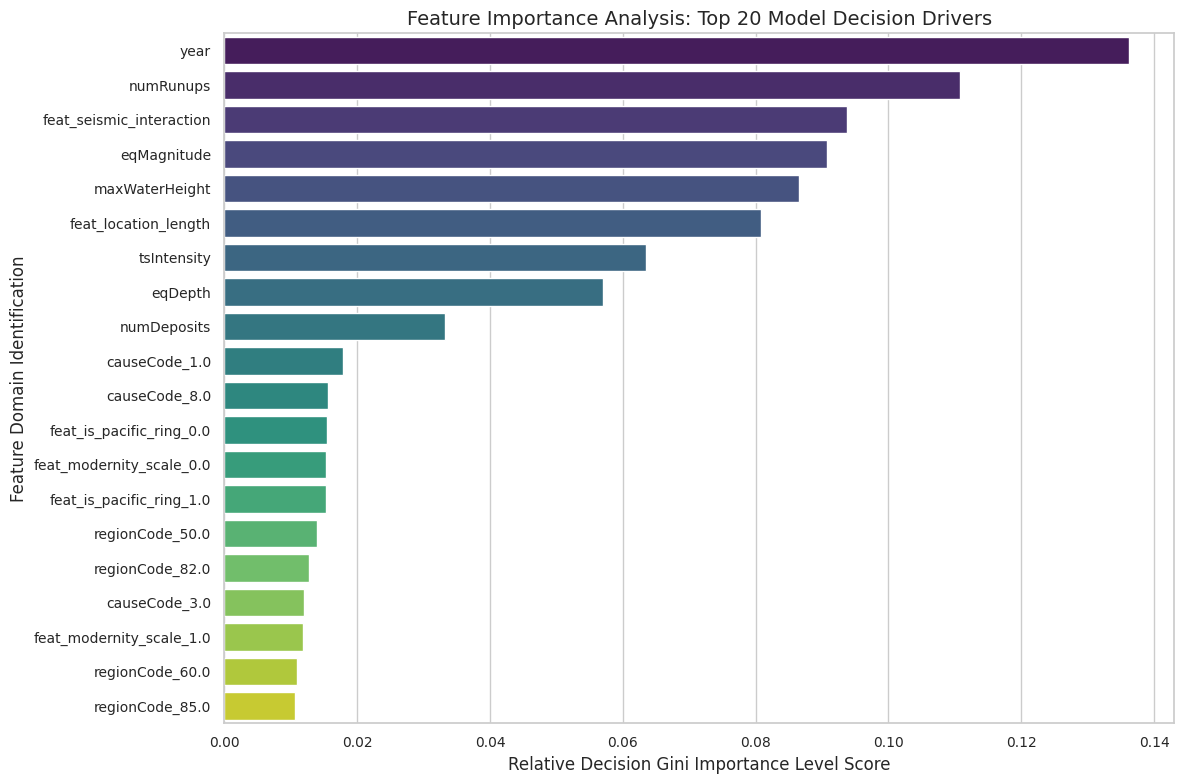

In [17]:
# Plot 2: Model Feature Importance Processing
cat_encoder = pipeline_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numerical_features + encoded_cat_features

feature_importances = pipeline_rf.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({"Feature": all_feature_names, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(20), palette=PALETTE_SEQUENTIAL, hue="Feature", legend=False)
plt.title("Feature Importance Analysis: Top 20 Model Decision Drivers")
plt.xlabel("Relative Decision Gini Importance Level Score")
plt.ylabel("Feature Domain Identification")
plt.tight_layout()
plt.show()

## Feature Importance Profile and Confusion Matrix Analysis
The confusion matrix heatmap shows that misclassifications are concentrated around adjacent ordinal levels, with the model frequently under-predicting catastrophic economic impacts (Class 4). The feature importance analysis reveals that `year` is the strongest predictor with a score of 0.136, followed closely by `numRunups` at 0.111. The dominant ranking of `year` confirms that historical logging trends and shifting economic valuations over time introduce significant variance into the target labels. The strong importance score for `numRunups` suggests that the physical footprint of a tsunami wave serves as an accurate proxy for its overall socio-economic damage. Physical features like `feat_seismic_interaction` (0.094) and `eqMagnitude` (0.091) function as secondary, supporting factors within the model's decision tree structure.

# 6. Structural Conclusion

- This end-to-end analytics pipeline provides a systematic framework for processing, analyzing, and modeling the historical NOAA NCEI Global Tsunami Events Database. The exploratory data analysis successfully quantified significant temporal reporting biases, illustrating an increase in coastal runup records from 1.0 per event in ancient times to over 57.78 in the modern digital era. Geospatial mapping verified heavy event clustering along major subduction zones, specifically the Pacific Ring of Fire, with Japan, the United States, and Indonesia emerging as the highest-risk nations. Physical feature analysis revealed a non-linear relationship between triggering earthquake magnitudes and resulting coastal wave heights, showing that seismic magnitude alone cannot predict tsunami severity.

- By implementing strict quality filtering based on event verification parameters and constructing domain-specific feature variables (such as interactive seismic index values and text-length information proxies), we built a high-confidence modeling sub-population of 883 entries. Within a pipeline structured to eliminate data leakage, a Random Forest multi-class classifier achieved a cross-validated accuracy of 45.33%, outperforming a Gradient Boosting framework. The final test diagnostics showed that while the model handles minor damage classifications well, separating adjacent intermediate and severe damage levels remains challenging. This confirms that physical hazard features must be combined with high-resolution regional asset infrastructure data to achieve more precise socio-economic risk classifications.